### Analisis de pelicula radiocromica para la posicion inicial de la fuente de braquiterapia

Realizaremos un procedimiento similar al del analisis de placas mensual.

### Librerias

In [1]:
import numpy as np
import scipy as sp
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftfreq
from scipy.fft import fftshift, ifftshift
from scipy.signal import convolve2d

import imageio

import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib import colormaps
import pint
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Layout, HBox, VBox

from PIL import Image

u = pint.UnitRegistry()

In [2]:
print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'okabe_ito', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_s

### Funciones auxiliares

In [3]:
def normalize_image(image):
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return normalized_image

def intensidad_del_campo(campo):
    intensidad_espectro_imagen = np.abs(campo)**2
    return intensidad_espectro_imagen


### Placa a analizar

Fue recomendado, casi que por obligacion usar las 3 capas RGB.

In [4]:
ruta_imagen = '/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/EPSON009.jpeg'

placa_analizada = cv2.bitwise_not(cv2.imread(ruta_imagen, 1))
placa_analizada_gray = cv2.bitwise_not(cv2.imread(ruta_imagen, 0))

In [5]:
tamano_pixel = 25.4/600 # Tamano del pixel a 600 dpi

QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no long

Puntos guardados (coordenadas [x, y]): [(225, 137), (234, 480)]


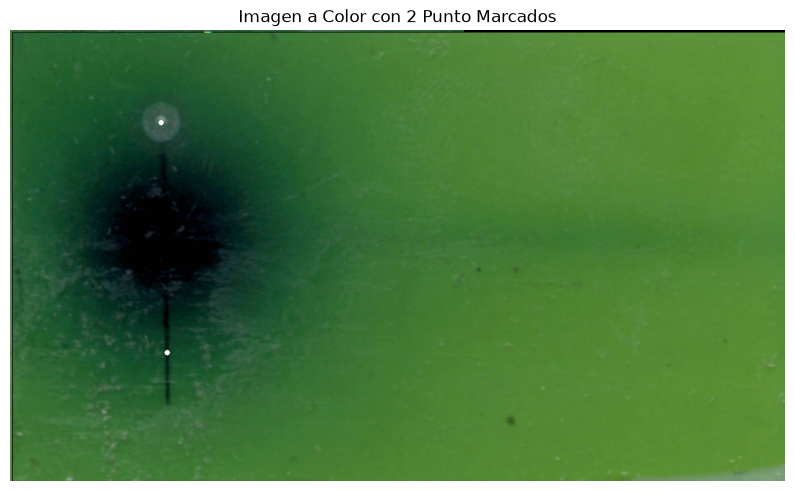

In [6]:
# --- 1. Aplicar mapa de color a la imagen base ---
# Convertimos el float32 [0.0, 1.0] a uint8 [0, 255] para aplicar el mapa de color de OpenCV
img_uint8 = (placa_analizada* 255).clip(0, 255).astype(np.uint8)

# Aplicar mapa de color (Puedes cambiar cv2.COLORMAP_JET por:
# COLORMAP_VIRIDIS, COLORMAP_HOT, COLORMAP_TURBO, COLORMAP_PLASMA, COLORMAP_BONE)
# placa_color_bgr = cv2.applyColorMap(img_uint8, cv2.COLORMAP_JET)

# Convertir de vuelta a float32 [0.0, 1.0] para trabajar uniformemente
placa_color = img_uint8.astype(np.float32) / 255.0

puntos = []


def seleccionar_puntos(event, x, y, flags, param):
    global puntos, placa_color

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 2:
        puntos.append((x, y))

        # Dibujar punto con intensidad de contraste sobre el mapa de calor
        # (1.0, 1.0, 1.0) = Blanco puro | (0.0, 0.0, 0.0) = Negro puro
        cv2.circle(placa_color, (x, y), 4, (1.0, 1.0, 1.0), -1)


# --- 2. Interfaz interactiva OpenCV ---
cv2.namedWindow("Seleccionar 2 Puntos", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Seleccionar 2 Puntos", seleccionar_puntos)
cv2.resizeWindow("Seleccionar 2 Puntos", 1280, 720)

while True:
    cv2.imshow("Seleccionar 2 Puntos", placa_color)

    key = cv2.waitKey(1) & 0xFF
    if key == 27 or len(puntos) == 2:
        if len(puntos) == 2:
            cv2.imshow("Seleccionar 2 Punto", placa_color)
            cv2.waitKey(300)
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

# --- 3. Renderizado inline dentro del Notebook ---
print(f"Puntos guardados (coordenadas [x, y]): {puntos}")

# Convertir BGR a RGB para mostrar exactamente lo mismo en Matplotlib
placa_color_rgb = cv2.cvtColor(
    (placa_color * 255).astype(np.uint8), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(placa_color_rgb)
plt.title("Imagen a Color con 2 Punto Marcados")
plt.axis("off")
plt.show()

plt.imsave('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_0.jpeg', placa_color_rgb)

Debemos ahora poder alinearla automaticamente, teniendo las coordenadas, podemos identificar la inclinacion respecto a la vertical.



In [7]:
tetha_0 = -1 * np.degrees(np.arctan((puntos[1][0] - puntos[0][0])/(puntos[1][1] - puntos[0][1])))
print(tetha_0)

-1.5030429212835306


Necesito identificar y especificar adecuadamente mi centro de rotacion, que debe ser el centro de la linea, aaahg.

In [8]:
centro_rotacion = ((puntos[1][0] + puntos[0][0])//2, (puntos[1][1] + puntos[0][1])//2)

print(centro_rotacion)

(229, 308)


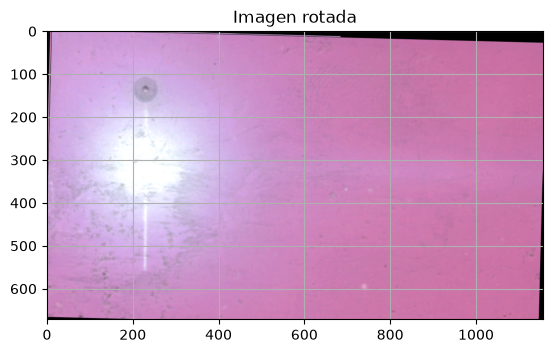

In [9]:
placa_matriz_transformacion = cv2.getRotationMatrix2D(
    centro_rotacion,
    tetha_0, 1)

placa_rotada = cv2.warpAffine(placa_analizada, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_color_rgb)[1], np.shape(placa_color_rgb)[0]))

plt.imshow(placa_rotada, cmap = 'jet')
plt.title('Imagen rotada')
plt.grid()
plt.show()

Pero ahora donde quedan esos puntos, los necesitamos para saber donde hacer los cortes.

In [10]:
type(puntos)

list

In [11]:
type(np.array(puntos))

numpy.ndarray

In [12]:
puntos

[(225, 137), (234, 480)]

In [13]:
np.shape(placa_matriz_transformacion)

(2, 3)

In [14]:
arr_puntos = np.array(puntos)

puntos_rotados_tetha = cv2.transform(
    arr_puntos.reshape(-1, 1, 2),
    placa_matriz_transformacion
)

puntos_rotados_tetha = puntos_rotados_tetha.reshape(-1, 2).tolist()

print(f"Nueva posicion puntos de referencia: {puntos_rotados_tetha}")

Nueva posicion puntos de referencia: [[229, 137], [229, 480]]


In [15]:
arr_puntos.reshape(-1, 1, 2)

array([[[225, 137]],

       [[234, 480]]])

In [16]:
type(puntos)

list

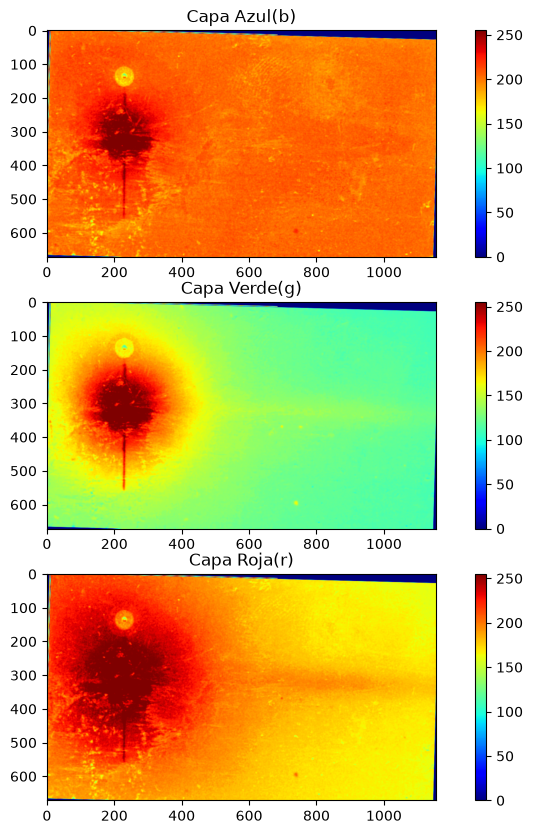

In [17]:
b, g, r = cv2.split(placa_rotada)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3) # Numero filas, columnas, posicion especifica.
plt.imshow(r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

In [18]:
type(b)

numpy.ndarray

In [19]:
cv2.bitwise_not(b)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(672, 1156), dtype=uint8)

## Perfil de la placa

Utilizaremos la misma estrategia para limpiar los bordes y evitar los artefactos en la periferia.

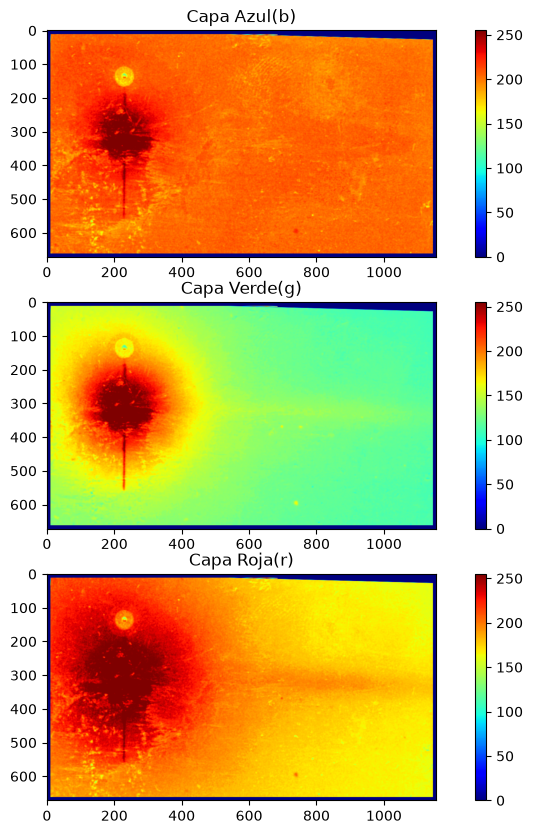

In [20]:
grosor_marco = 20

rectangulo_borde_b = cv2.rectangle(b, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)
rectangulo_borde_g = cv2.rectangle(g, (0, 0), (np.shape(g)[1], np.shape(g)[0]), 0, grosor_marco)
rectangulo_borde_r = cv2.rectangle(r, (0, 0), (np.shape(r)[1], np.shape(r)[0]), 0, grosor_marco)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(rectangulo_borde_b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(rectangulo_borde_g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(rectangulo_borde_r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

In [21]:
np.shape(b)

(672, 1156)

## Acondicionamiento de la imagen

Obligatoriamente hay que invertir estas imagenes porque sino la curva queda "alreves". Porque como vemos  continuacion sin invertir antes la imagen, el maximo y el valor de la pelicula virgen coinciden, por lo que la normalizacion falla.

Aqui puede que no sea necesario hacer la correccion de piso y techo porque no debemos medir alturas solo alineacion.

In [22]:
zona_ignorada = grosor_marco + 1

valor_pelicula_b = int(rectangulo_borde_b[
    np.shape(rectangulo_borde_b)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_b)[1] - zona_ignorada
])
print(f"Valor de centro blue: {valor_pelicula_b}")

valor_pelicula_g = int(rectangulo_borde_g[
    np.shape(rectangulo_borde_g)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_g)[1] - zona_ignorada
]) 
print(f"Valor de centro green: {valor_pelicula_g}")

valor_pelicula_r = int(rectangulo_borde_r[
    np.shape(rectangulo_borde_r)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_r)[1] - zona_ignorada
])
print(f"Valor de centro red: {valor_pelicula_r}")

Valor de centro blue: 203
Valor de centro green: 113
Valor de centro red: 162


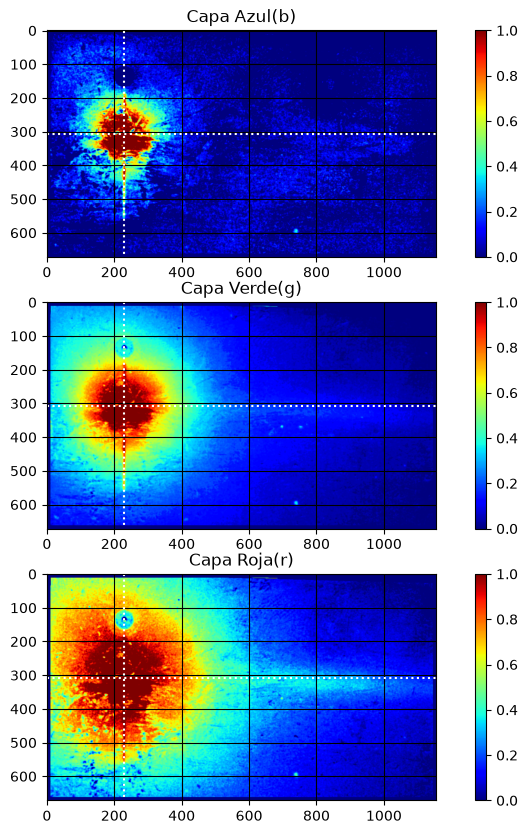

In [23]:
placa_recorte_borde_b = normalize_image(
    np.where(
        rectangulo_borde_b <= valor_pelicula_b,
        valor_pelicula_b, rectangulo_borde_b
    )
)
placa_recorte_borde_g = normalize_image(
    np.where(
        rectangulo_borde_g <= valor_pelicula_g,
        valor_pelicula_g, rectangulo_borde_g
    )
)
placa_recorte_borde_r = normalize_image(
    np.where(
        rectangulo_borde_r <= valor_pelicula_r,
        valor_pelicula_r, rectangulo_borde_r
    )
)


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(placa_recorte_borde_b, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_b)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_b)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(placa_recorte_borde_g, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_g)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_g)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(placa_recorte_borde_r, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_r)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_r)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Roja(r)')

plt.show()

In [24]:
np.shape(placa_recorte_borde_r)

(672, 1156)

In [25]:
centro_rotacion

(229, 308)

In [26]:
centro_rotacion[0]

229

Definiremos nuevamente el valor de la pelicula virgen, esta vez preferible en la esquina mas alejada.

Dado que el maximo no esta en un solo punto sino encerrado en un area de igual intensidad relativa, entonces lo que debemos hacer es sacarle el punto medio a esta region, preferiblemente primero garantizando que estamos en el centro exacto de la mancha, como? Sacamos el array.

Con esos dos puntos podemos trazar un centro o un eje sobre el cual hacer el corte a nivel vertical, debe pasar por el centro de la recta, no necesariamente verticalmente, sino primero horizontalemnte porque lo paralelo de la recta respecto a la vertical es lo que define la posicion vertical que debemos analizar, luego, elegiremos el centro de la region del maximo que sera el punto de corte horizontal.

Cuando roto la placa ya no coinciden las coordenadas de los centros. Con donde queda realmente el centro.

In [27]:
np.shape(placa_recorte_borde_b)[1] - centro_rotacion[0] # Check

927

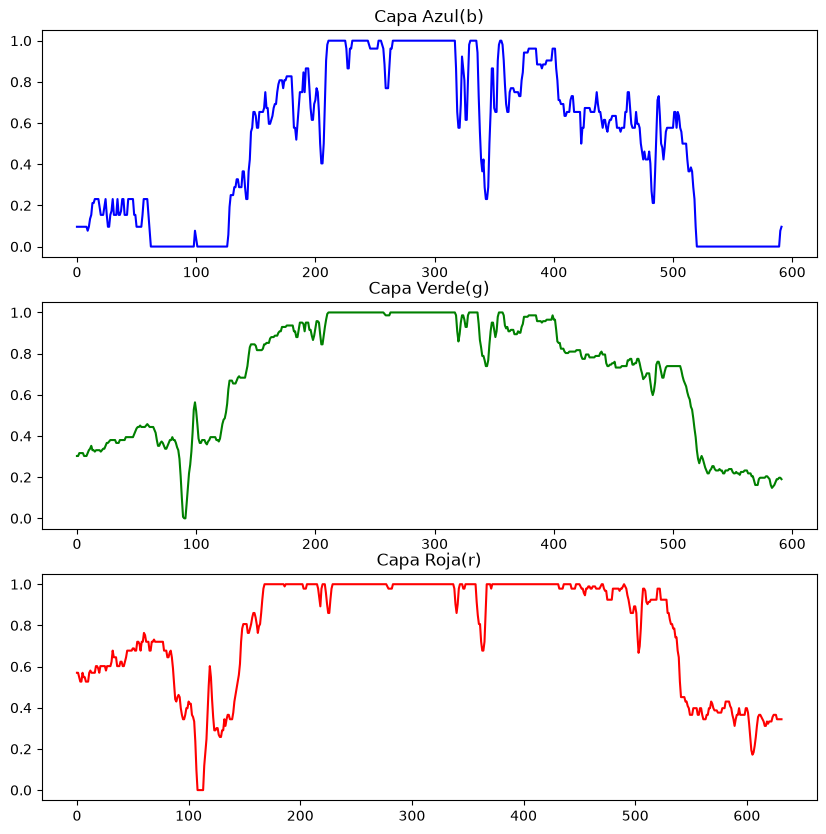

In [28]:
b_inplane = np.rot90(placa_recorte_borde_b)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_b)[0] - grosor_marco]

g_inplane = np.rot90(placa_recorte_borde_g)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_g)[0] - grosor_marco]

r_inplane = np.rot90(placa_recorte_borde_r)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_r)[0] - grosor_marco]

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_inplane[grosor_marco:np.shape(b_inplane)[0] - grosor_marco], color = 'blue')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_inplane[grosor_marco:np.shape(g_inplane)[0] - grosor_marco], color = 'green')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_inplane, color = 'red')
plt.title('Capa Roja(r)')

plt.show()

El corte anterior realmente no tiene mucha informacion util, pues es verdad, estamos haciendo el corte justo por donde pasa la linea. Ya tenemos toda la informacion de la linea, incluso el centro, es alli por donde debemos hacer el corte. Tecnicamente no deberia ser importante la posicion a lo largo de la linea sobre la cual hagamos el corte, porque este o no centrada la mancha, esta es simetrica respecto a su centro, lo que significa que midiendo la meseta podremos encontrar su centro el cual va a estar paralelo a lo largo de toda la vertical con respecto a la linea de referencia.

Hay que tener en cuenta que la aplicacion funciona con python 3.11.16, changos.

Centro de la region del minimo en Placa_Blue: 207.0
Desfase al centro de referencia: 22.0
Desfase al centro de referencia: 0.931 mm
Centro de la region del minimo en Placa_Green: 209.5
Desfase al centro de referencia: 19.5
Desfase al centro de referencia: 0.826 mm
Centro de la region del minimo en Placa_Red: 182.5
Desfase al centro de referencia: 46.5
Desfase al centro de referencia: 1.969 mm


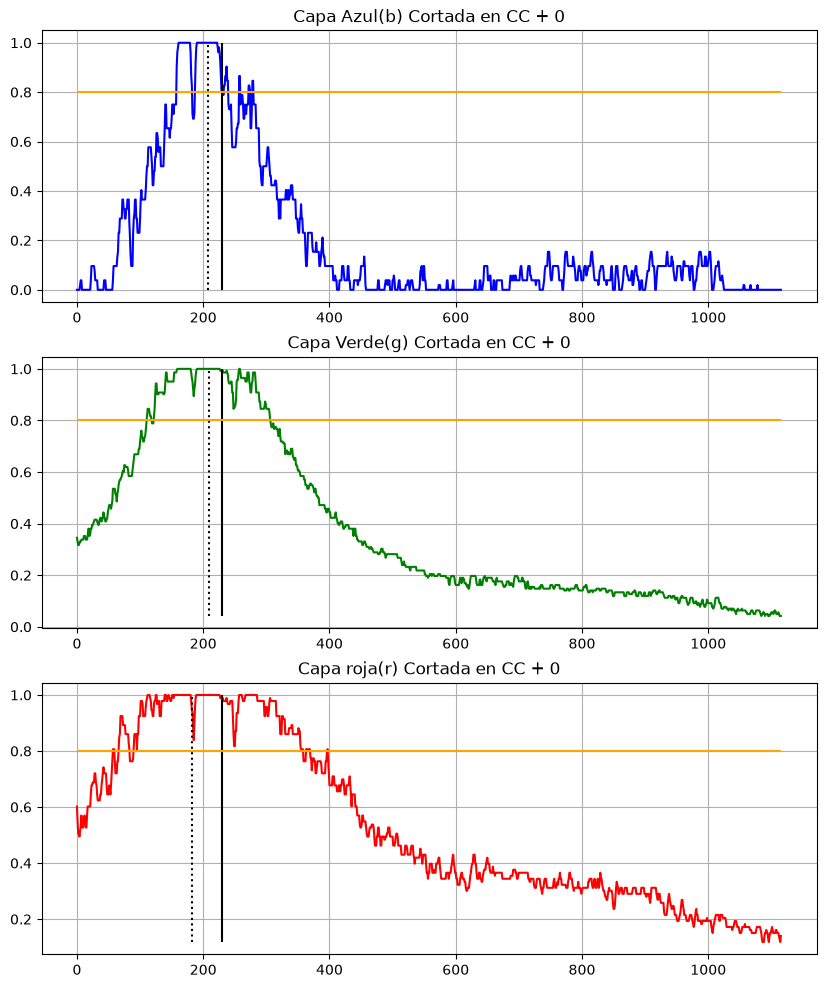

In [29]:
crr_cc = 0

b_crossplane = placa_recorte_borde_b[
    centro_rotacion[1] - crr_cc
][grosor_marco:np.shape(placa_recorte_borde_b)[1] - grosor_marco]

g_crossplane = placa_recorte_borde_g[
    centro_rotacion[1] - crr_cc
][grosor_marco:np.shape(placa_recorte_borde_g)[1] - grosor_marco]

r_crossplane = placa_recorte_borde_r[
    centro_rotacion[1] - crr_cc
][grosor_marco:np.shape(placa_recorte_borde_r)[1] - grosor_marco]


delta_0 = 0.8 # 80% de diferencia con el valor del centro de referencia

# Hallamos los centros para graficarlos de una vez
if b_crossplane[0] < (delta_0 * np.max(b_crossplane)):

    arr_plan_b = np.where(b_crossplane == np.max(b_crossplane))[0]
    ancho_plan_b = len(arr_plan_b)

    centro_plan_b = (ancho_plan_b/2) + int(arr_plan_b[0]) + grosor_marco 
    diff_centro_b = centro_rotacion[0] - centro_plan_b
    print(f"Centro de la region del minimo en Placa_Blue: {centro_plan_b}")
    print(f"Desfase al centro de referencia: {diff_centro_b}")
    print(f"Desfase al centro de referencia: {np.round(diff_centro_b * tamano_pixel, 3)} mm")
else:
    print("No se encontró un mínimo en la capa azul dentro del rango permitido.")
    
if g_crossplane[0] < (delta_0 * np.max(g_crossplane)):

    arr_plan_g = np.where(g_crossplane == np.max(g_crossplane))[0]
    ancho_plan_g = len(arr_plan_g)

    centro_plan_g = (ancho_plan_g/2) + int(arr_plan_g[0]) + grosor_marco
    diff_centro_g = centro_rotacion[0] - centro_plan_g
    print(f"Centro de la region del minimo en Placa_Green: {centro_plan_g}")
    print(f"Desfase al centro de referencia: {diff_centro_g}")
    print(f"Desfase al centro de referencia: {np.round(diff_centro_g * tamano_pixel, 3)} mm")
else:
    print("No se encontró un mínimo en la capa verde dentro del rango permitido.")

if r_crossplane[0] < (delta_0 * np.max(r_crossplane)):

    arr_plan_r = np.where(r_crossplane == np.max(r_crossplane))[0]
    ancho_plan_r = len(arr_plan_r)

    centro_plan_r = (ancho_plan_r/2) + int(arr_plan_r[0]) +grosor_marco
    diff_centro_r = centro_rotacion[0] - centro_plan_r
    print(f"Centro de la region del minimo en Placa_Red: {centro_plan_r}")
    print(f"Desfase al centro de referencia: {diff_centro_r}")
    print(f"Desfase al centro de referencia: {np.round(diff_centro_r * tamano_pixel, 3)} mm")
else:
    print("No se encontró un mínimo en la capa roja dentro del rango permitido.")

# Graficamos
plt.figure(figsize = (10, 12))

plt.subplot(3, 1, 1)
plt.plot(b_crossplane, color = 'blue')

if b_crossplane[0] < (delta_0 * np.max(b_crossplane)):
    plt.vlines(centro_plan_b, np.min(b_crossplane), np.max(b_crossplane), colors = 'Black', linestyles = ':')
    plt.vlines(centro_rotacion[0], np.min(b_crossplane), np.max(b_crossplane),
                colors = 'Black', linestyles = '-')

plt.hlines(delta_0 * np.max(b_crossplane), 0, np.shape(b_crossplane)[0], colors = "Orange", linestyles = '-')
plt.grid()
plt.title(f"Capa Azul(b) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 2)
plt.plot(g_crossplane, color = 'green')

if g_crossplane[0] < (delta_0 * np.max(g_crossplane)):
    plt.vlines(centro_plan_g, np.min(g_crossplane), np.max(g_crossplane), colors = 'Black', linestyles = ':')
    plt.vlines(centro_rotacion[0], np.min(g_crossplane), np.max(g_crossplane),
                colors = 'Black', linestyles = '-')

plt.hlines(delta_0 * np.max(g_crossplane), 0, np.shape(g_crossplane)[0], colors = "Orange", linestyles = '-')
plt.grid()
plt.title(f"Capa Verde(g) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 3)
plt.plot(r_crossplane, color = 'red')

if r_crossplane[0] < (delta_0 * np.max(r_crossplane)):
    plt.vlines(centro_plan_r, np.min(r_crossplane), np.max(r_crossplane), colors = 'Black', linestyles = ':')
    plt.vlines(centro_rotacion[0], np.min(r_crossplane), np.max(r_crossplane),
               colors = 'Black', linestyles = '-')

plt.hlines(delta_0 * np.max(r_crossplane), 0, np.shape(r_crossplane)[0], colors = "Orange", linestyles = '-')
plt.grid()
plt.title(f"Capa roja(r) Cortada en CC + {crr_cc}")

plt.show()

In [30]:
arr_plan_r

array([112, 113, 114, 115, 125, 126, 139, 140, 141, 145, 151, 152, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180,
       189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201,
       202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214,
       215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 257,
       258, 259, 260, 261, 267, 268, 269, 270, 271, 272, 273, 274, 275,
       276, 277, 278, 279, 280, 281, 282, 283, 284, 285])

Debemos comprobar si el marco realmente mide 'grosor_marco' en cada borde, sino esto nos esta afectando la medida.

El procedimiento anterior esta bien, pero hay mucho ruido que afecta las medidas y la forma en la que se toman, es por esto que lo mejor es generar un pequeno barrido de cortes crossplane simetricamente respecto al centro y sacar un valor medio o la mediana, porque puede que hayan valores muy extremos.

In [31]:
# Vamos a generar un barrido simetrico crossplane respecto al centro.

valores_crossplane_b = []
valores_crossplane_g = []
valores_crossplane_r = []

ancho_barrido = 300 # pixeles

if b_crossplane[0] < (delta_0 * np.max(b_crossplane)):

    for i in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

        b_crossplane_barrido = placa_recorte_borde_b[
            i
            ][grosor_marco:np.shape(placa_recorte_borde_b)[1] - grosor_marco]
        
        arr_plan_b_barrido = np.where(b_crossplane_barrido == np.max(b_crossplane_barrido))[0]
        ancho_plan_b_barrido = len(arr_plan_b_barrido)
        
        if arr_plan_b_barrido.size > 0:
            centro_plan_b_barrido = (ancho_plan_b_barrido//2) + int(arr_plan_b_barrido[0]) + grosor_marco
            diff_centro_b_barrido = centro_rotacion[0] - centro_plan_b_barrido
            valores_crossplane_b.append(diff_centro_b_barrido * tamano_pixel)    
    
else:
    print("No se encontró un mínimo en la capa azul dentro del rango permitido.")
    
if g_crossplane[0] < (delta_0 * np.max(g_crossplane)):

    for i in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

        g_crossplane_barrido = placa_recorte_borde_g[
            i
            ][grosor_marco:np.shape(placa_recorte_borde_g)[1] - grosor_marco] # Por esto es que debemos sumar el grosor del marco al encontrar el centro de la region
        
        arr_plan_g_barrido = np.where(g_crossplane_barrido == np.max(g_crossplane_barrido))[0]
        ancho_plan_g_barrido = len(arr_plan_g_barrido)
        
        if arr_plan_g_barrido.size > 0:
            centro_plan_g_barrido = (ancho_plan_g_barrido//2) + int(arr_plan_g_barrido[0]) + grosor_marco
            diff_centro_g_barrido = centro_rotacion[0] - centro_plan_g_barrido
            valores_crossplane_g.append(diff_centro_g_barrido * tamano_pixel)

else:
    print("No se encontró un mínimo en la capa verde dentro del rango permitido.")

if r_crossplane[0] < (delta_0 * np.max(r_crossplane)):

    for i in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

        r_crossplane_barrido = placa_recorte_borde_r[
            i
            ][grosor_marco:np.shape(placa_recorte_borde_r)[1] - grosor_marco]
        
        arr_plan_r_barrido = np.where(r_crossplane_barrido == np.max(r_crossplane_barrido))[0]
        ancho_plan_r_barrido = len(arr_plan_r_barrido)
        
        if arr_plan_r_barrido.size > 0:
            centro_plan_r_barrido = (ancho_plan_r_barrido//2) + int(arr_plan_r_barrido[0]) + grosor_marco
            diff_centro_r_barrido = centro_rotacion[0] - centro_plan_r_barrido
            valores_crossplane_r.append(diff_centro_r_barrido * tamano_pixel)

else:
    print("No se encontró un mínimo en la capa roja dentro del rango permitido.")


mediana_b = np.median(valores_crossplane_b)
mediana_g = np.median(valores_crossplane_g)
mediana_r = np.median(valores_crossplane_r)

media_b = np.mean(valores_crossplane_b)
media_g = np.mean(valores_crossplane_g)
media_r = np.mean(valores_crossplane_r)

print(f"Mediana de los desfases en la capa azul: {np.round(mediana_b, 3)} mm")
print(f"Mediana de los desfases en la capa verde: {np.round(mediana_g, 3)} mm")
print(f"Mediana de los desfases en la capa roja: {np.round(mediana_r, 3)} mm")

print(f"Media de los desfases en la capa azul: {np.round(media_b, 3)} mm")
print(f"Media de los desfases en la capa verde: {np.round(media_g, 3)} mm")
print(f"Media de los desfases en la capa roja: {np.round(media_r, 3)} mm")


Mediana de los desfases en la capa azul: -0.021 mm
Mediana de los desfases en la capa verde: 0.0 mm
Mediana de los desfases en la capa roja: 0.995 mm
Media de los desfases en la capa azul: 0.415 mm
Media de los desfases en la capa verde: 0.262 mm
Media de los desfases en la capa roja: 0.956 mm


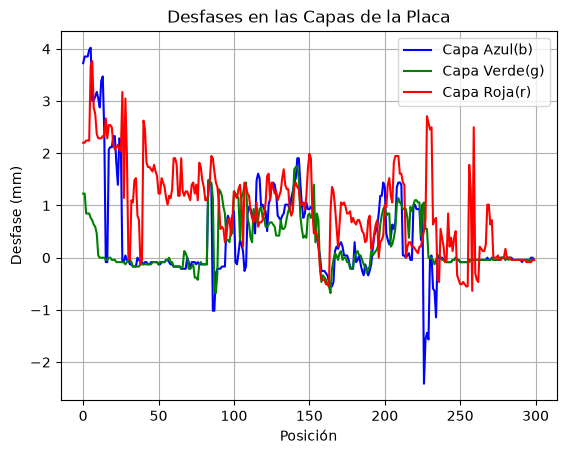

In [32]:
plt.plot(valores_crossplane_b, color = 'blue', label = 'Capa Azul(b)')
plt.plot(valores_crossplane_g, color = 'green', label = 'Capa Verde(g)')
plt.plot(valores_crossplane_r, color = 'red', label = 'Capa Roja(r)')
plt.xlabel('Posición')
plt.ylabel('Desfase (mm)')
plt.title('Desfases en las Capas de la Placa')
plt.legend()
plt.grid()
plt.show()

Es util hacer un barrido de cortes crossplane en la region cercana al centro, sin embargo, muy lejos de el, el ancho que se empieza a detectar es el de la linea dibujada, por lo que el analisis lo que empieza es a medir el ancho de esta linea, que marca la referencia, respecto al centro de la referencia, por lo que termina empujando el error a cero entre mas larga sea la linea y entre mas ancha sea la region del barrido.

In [33]:
np.where(g_crossplane == valor_pelicula_g)[0]

array([], dtype=int64)

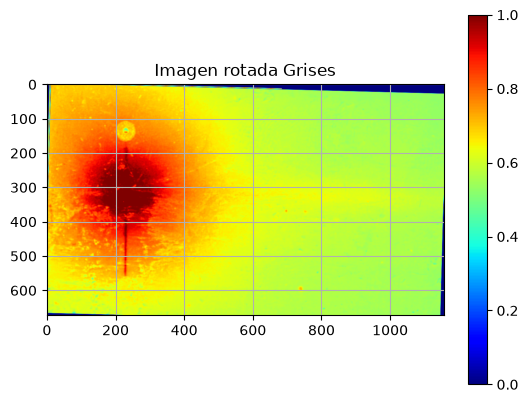

In [34]:
placa_rotada_gray = cv2.warpAffine(placa_analizada_gray, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_analizada_gray)[1], np.shape(placa_analizada_gray)[0]))

placa_gris = normalize_image(placa_rotada_gray)

plt.imshow(placa_gris, cmap = 'jet')
plt.title('Imagen rotada Grises')
plt.grid()
plt.colorbar()
plt.show()

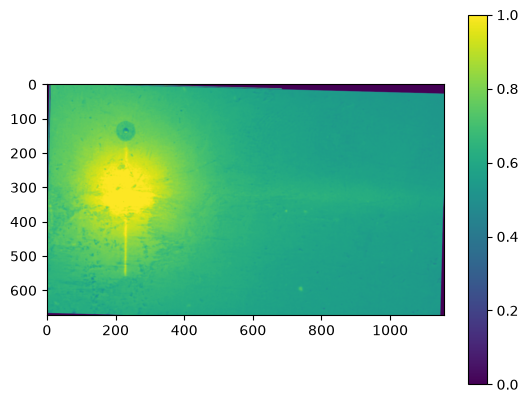

In [35]:
placa_gris_borde = placa_gris

plt.imshow(placa_gris_borde)
plt.colorbar()
plt.show()

In [36]:
valor_pelicula_centro_gray = placa_gris_borde[centro_rotacion[1]][centro_rotacion[0]] 
print(f"Valor de centro blue: {valor_pelicula_centro_gray}")

Valor de centro blue: 1.0


In [37]:
np.shape(placa_recorte_borde_b)

(672, 1156)

Centro de la region del minimo en Placa_Gray; 209
Desfase al centro de referencia: 20 px
Desfase al centro de referencia: 0.8466666666666667 mm


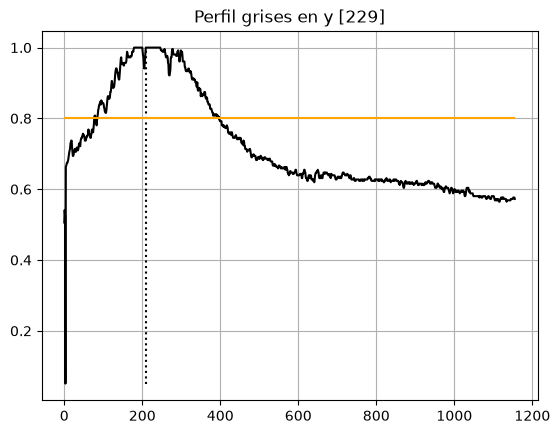

In [38]:
gray_crossplane = placa_gris_borde[
    centro_rotacion[1]
]

delta_gray = 0.8

arr_plan_gray = np.where(gray_crossplane == np.max(gray_crossplane))[0]
ancho_plan_gray = len(arr_plan_gray)

centro_plan_gray = (ancho_plan_gray//2) + int(arr_plan_gray[0])
diff_centro_gray = centro_rotacion[0] - (centro_plan_gray)
print(f"Centro de la region del minimo en Placa_Gray; {centro_plan_gray}")
print(f"Desfase al centro de referencia: {diff_centro_gray} px")
print(f"Desfase al centro de referencia: {diff_centro_gray * tamano_pixel} mm")

plt.plot(gray_crossplane, color = 'Black')
plt.grid()
plt.title(f"Perfil grises en y [{centro_rotacion[0]}]")
plt.vlines(centro_plan_gray, np.min(gray_crossplane), np.max(gray_crossplane), colors = 'Black', linestyles = ':')
plt.hlines(delta_gray * np.max(gray_crossplane), 
           0, len(gray_crossplane), colors = 'Orange', linestyles = '-')

plt.show()

In [39]:
gray_crossplane[0]

np.float64(0.5058823529411764)

In [40]:
gray_crossplane[0] <= (0.95 * np.max(gray_crossplane))

np.True_

In [41]:
valores_crossplane_gray = []

if gray_crossplane[0] < (delta_gray * np.max(gray_crossplane)):

    for i in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

        gray_crossplane_barrido = placa_gris_borde[
            i
            ][grosor_marco:np.shape(placa_gris_borde)[1] - grosor_marco]
        
        arr_plan_gray_barrido = np.where(gray_crossplane_barrido == np.max(gray_crossplane_barrido))[0]
        ancho_plan_gray_barrido = len(arr_plan_gray_barrido)
        
        if arr_plan_gray_barrido.size > 0:
            centro_plan_gray_barrido = (ancho_plan_gray_barrido//2) + int(arr_plan_gray_barrido[0])
            diff_centro_gray_barrido = centro_rotacion[0] - (centro_plan_gray_barrido + grosor_marco)
            valores_crossplane_gray.append(diff_centro_gray_barrido * tamano_pixel)

else:
    print("No se encontró un mínimo en la capa gris dentro del rango permitido.")

print(f"Mediana de los desfases en la capa gris: {np.round(np.median(valores_crossplane_gray), 3)} mm")
print(f"Media de los desfases en la capa gris: {np.round(np.mean(valores_crossplane_gray), 3)} mm")

Mediana de los desfases en la capa gris: 0.0 mm
Media de los desfases en la capa gris: 0.304 mm


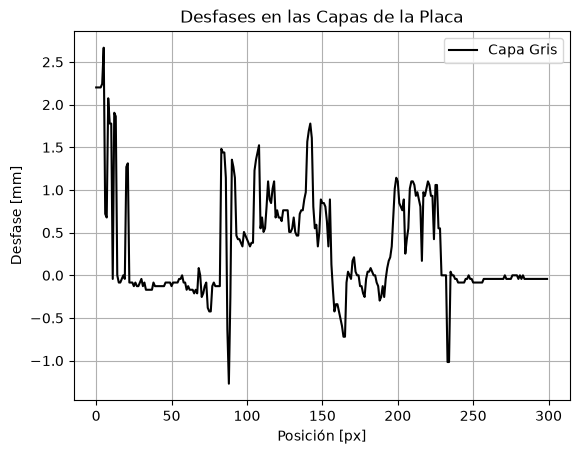

In [42]:
plt.plot(valores_crossplane_gray, color = 'black', label = 'Capa Gris')
plt.xlabel('Posición [px]')
plt.ylabel('Desfase [mm]')
plt.title('Desfases en las Capas de la Placa')
plt.legend()
plt.grid()
plt.show()

In [43]:
# from ipywidgets import IntSlider, Output, interactive_output

# x = IntSlider(
#         min = centro_rotacion[1] - ancho_barrido//2,
#         max = centro_rotacion[1] + ancho_barrido//2,
#         step = 1,
#         description="Posición Y",
#         continuous_update=False
#     )

# def graficar_perfil_gray_barrido(x):

#     gray_crossplane_barrido = placa_gris_borde[x, grosor_marco:np.shape(placa_gris_borde)[1] - grosor_marco]

#     columnas = np.arange(grosor_marco, np.shape(placa_gris_borde)[1] - grosor_marco)
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#     ax1.imshow(placa_gris_borde, cmap='gray')
#     ax2.plot(columnas, gray_crossplane_barrido, color="#1f77b4", lw=2)

#     plt.tight_layout()
#     plt.show()

#     plt.close(fig)

# out = interactive_output(graficar_perfil_gray_barrido, {'x': x})

# display(x, out)

## Visualizacion de los perfiles del barrido

## Calibracion

Vamos a crear una distribucion artificial para calibrar la placa.

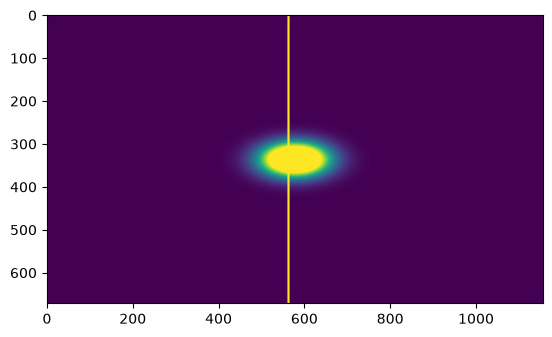

In [44]:
ancho, alto = np.shape(placa_analizada)[0], np.shape(placa_analizada)[1]
centro_xcal, centro_ycal = alto//2, ancho//2
sigma = 75

x_cal = np.arange(0, alto)
y_cal = np.arange(0, ancho)
X, Y = np.meshgrid(x_cal, y_cal)

frente_onda = np.exp(-(2 * (X - centro_xcal) ** 2 + 8 * (Y - centro_ycal) ** 2) / (2 * sigma ** 2))

frente_onda_8bit = np.uint8(frente_onda * 255)

dev_center_cal = centro_xcal - 15
cv2.line(frente_onda_8bit, (dev_center_cal, 0), (dev_center_cal, np.shape(frente_onda_8bit)[1]), 0.5 * 255, 3)

frente_saturado = np.where(frente_onda_8bit >= (0.5 * 255), (0.5 * 255), frente_onda_8bit)

plt.imshow(frente_saturado)
plt.show()

plt.imsave('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_cal0.jpeg', frente_saturado)

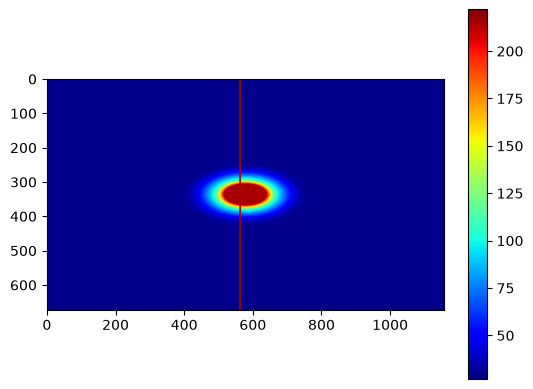

In [45]:
placa_cal = cv2.imread('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_cal0.jpeg', 0)

plt.imshow(placa_cal, cmap = 'jet')
plt.colorbar()
plt.show()